# Hard coal+CCS NPV simulation

Run the hard coal+CCS electricity Monte Carlo simulation and visualize the resulting NPV distribution.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity_npv_monte_carlo import simulate_hard_coal_ccs_npv

In [2]:
SAMPLE_SIZE = 1000000
#RANDOM_SEED = 42

rng = np.random.default_rng() 
simulation = simulate_hard_coal_ccs_npv(size=SAMPLE_SIZE, rng=rng)
results = pd.DataFrame(simulation)

results.head()

,run_id,technology,annual_output_mwh,full_load_hours_per_year,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,fuel_consumption_mwh_th_per_mwh_e,...,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,lifetime_output_mwh,npv_eur_per_mwh,npv_million_eur_per_mwh
0,0,hard_coal_ccs,1000000.0,4100.0,243.902439,243902.439024,4022.460433,75.277580,9.280503,3.225794,...,94070000.0,1.836039e+07,9.280503e+06,5.075358e+07,6.571266e+06,9.104270e+06,-8.839019e+08,25000000.0,-35.356075,-0.000035
1,1,hard_coal_ccs,1000000.0,4100.0,243.902439,243902.439024,3963.325606,102.570179,8.805119,3.124196,...,94070000.0,2.501712e+07,8.805119e+06,4.304292e+07,4.489042e+06,1.271580e+07,-8.309265e+08,25000000.0,-33.237058,-0.000033
2,2,hard_coal_ccs,1000000.0,4100.0,243.902439,243902.439024,3145.735170,103.593457,8.893378,3.232408,...,94070000.0,2.526670e+07,8.893378e+06,3.660923e+07,4.661948e+06,1.863874e+07,-5.682881e+08,25000000.0,-22.731523,-0.000023
3,3,hard_coal_ccs,1000000.0,4100.0,243.902439,243902.439024,3560.326708,81.459504,9.627083,3.115755,...,94070000.0,1.986817e+07,9.627083e+06,3.397386e+07,6.091093e+06,2.450980e+07,-6.067358e+08,25000000.0,-24.269431,-0.000024
4,4,hard_coal_ccs,1000000.0,4100.0,243.902439,243902.439024,3261.063568,90.669570,10.781613,3.178833,...,94070000.0,2.211453e+07,1.078161e+07,4.214081e+07,6.446094e+06,1.258696e+07,-6.610184e+08,25000000.0,-26.440737,-0.000026


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_mwh = results["npv_eur_per_mwh"]
npv_million_eur_per_mwh = results["npv_million_eur_per_mwh"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/MWh"
        ),
        npv_million_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR/MWh"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/MWh,NPV million EUR/MWh
count,1000000.000000,1000000.000000,1000000.000000
mean,-795.087957,-31.803518,-0.000032
std,172.644163,6.905767,0.000007
min,-1427.503272,-57.100131,-0.000057
5%,-1075.281327,-43.011253,-0.000043
50%,-795.008793,-31.800352,-0.000032
95%,-518.512716,-20.740509,-0.000021
max,-307.385262,-12.295410,-0.000012


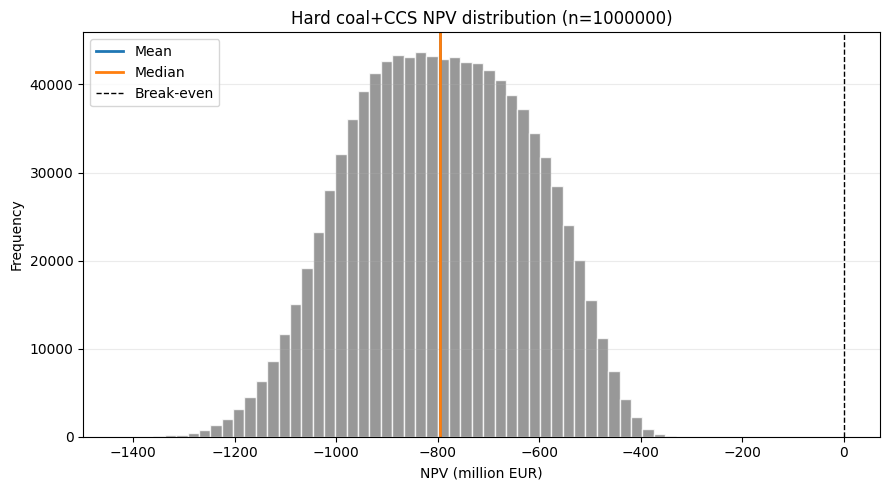

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Hard coal+CCS NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

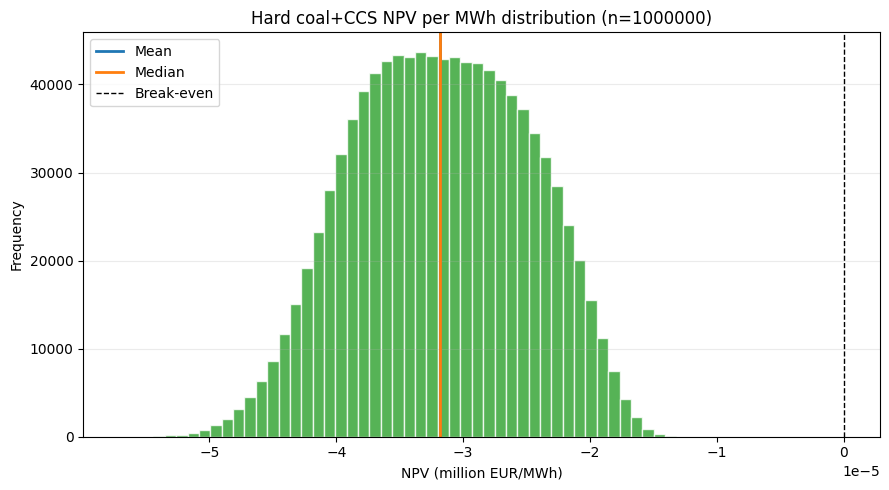

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_million_eur_per_mwh,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_million_eur_per_mwh.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_million_eur_per_mwh.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Hard coal+CCS NPV per MWh distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR/MWh)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur           94.070000
annual_fixed_opex_eur        21.087938
annual_variable_opex_eur     11.273968
annual_fuel_cost_eur         38.265568
annual_emissions_cost_eur     4.797994
annual_net_cash_flow_eur     18.644532
Name: Mean annual value, million EUR, dtype: float64